#BestFirstSearch

In [ ]:
# Graph according to the image
graph1 = {
    'S': ['A', 'B', 'C'],
    'A': ['D', 'E'],
    'B': ['F', 'G'],
    'C': ['H'],
    'D': [],
    'E': [],
    'F': [],
    'G': [],
    'H': ['I', 'J'],
    'I': ['K', 'L', 'M'],
    'J': [],
    'K': [],
    'L': [],
    'M': []
}

# Heuristic values from the image
heuristic1 = {
    'S': 0,
    'A': 3,
    'B': 6,
    'C': 5,
    'D': 9,
    'E': 8,
    'F': 12,
    'G': 14,
    'H': 7,
    'I': 5,
    'J': 6,
    'K': 1,
    'L': 10,
    'M': 2
}

# Greedy Best First Search
def greedy_bfs(graph, start, goal):

    frontier = [(start, heuristic1[start])]
    visited = set()
    came_from = {start: None}

    while frontier:

        # sort frontier based on heuristic
        frontier.sort(key=lambda x: x[1])

        current_node, _ = frontier.pop(0)

        if current_node in visited:
            continue

        print(current_node, end=" ")

        visited.add(current_node)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node)
                current_node = came_from[current_node]

            path.reverse()
            print("\nGoal found. Path:", path)
            return

        for neighbor in graph[current_node]:
            if neighbor not in visited:
                frontier.append((neighbor, heuristic1[neighbor]))
                came_from[neighbor] = current_node

    print("\nGoal not found")


print("Greedy Best First Search Traversal:")
greedy_bfs(graph1, 'S', 'J')

Greedy Best First Search Traversal:
S A C B H I K M J 
Goal found. Path: ['S', 'C', 'H', 'J']


#**Local Beam Search**

In [2]:
# Graph according to the image
graph1 = {
    'S': ['A', 'B', 'C'],
    'A': ['D', 'E'],
    'B': ['F', 'G'],
    'C': ['H'],
    'D': [],
    'E': [],
    'F': [],
    'G': [],
    'H': ['I', 'J'],
    'I': ['K', 'L', 'M'],
    'J': [],
    'K': [],
    'L': [],
    'M': []
}

# Heuristic values
heuristic1 = {
    'S': 0,
    'A': 3,
    'B': 6,
    'C': 5,
    'D': 9,
    'E': 8,
    'F': 12,
    'G': 14,
    'H': 7,
    'I': 5,
    'J': 6,
    'K': 1,
    'L': 10,
    'M': 2
}


def beam_search(graph, start, goal, beam_width):

    frontier = [(start, heuristic1[start])]   # same as GBFS
    visited = set()
    came_from = {start: None}

    while frontier:

        # heuristic based sorting
        frontier.sort(key=lambda x: x[1])

        # sirf beam width based on best nodes
        frontier = frontier[:beam_width]

        next_frontier = []

        for current_node, _ in frontier:

            if current_node in visited:
                continue

            print(current_node, end=" ")

            visited.add(current_node)

            if current_node == goal:

                path = []
                while current_node is not None:
                    path.append(current_node)
                    current_node = came_from[current_node]

                path.reverse()
                print("\nGoal Found. Path:", path)
                return

            for neighbor in graph[current_node]:
                if neighbor not in visited:
                    next_frontier.append((neighbor, heuristic1[neighbor]))
                    came_from[neighbor] = current_node

        frontier = next_frontier

    print("\nGoal not found")


print("Beam Search Traversal:")
beam_search(graph1, 'S', 'I', beam_width=2)

Beam Search Traversal:
[('S', 0)] front
S [('A', 3), ('C', 5)] front
A C [('H', 7), ('E', 8)] front
H E [('I', 5), ('J', 6)] front
I 
Goal Found. Path: ['S', 'C', 'H', 'I']


In [ ]:
import heapq

###**Beam search Explores multiple promising paths, but not all (like BFS).**

In [ ]:
# Graph according to the image
graph1 = {
    'S': ['A', 'B', 'C'],
    'A': ['D', 'E'],
    'B': ['F', 'G'],
    'C': ['H'],
    'D': [],
    'E': [],
    'F': [],
    'G': [],
    'H': ['I', 'J'],
    'I': ['K', 'L', 'M'],
    'J': [],
    'K': [],
    'L': [],
    'M': []
}

# Heuristic values
heuristic1 = {
    'S': 0,
    'A': 3,
    'B': 6,
    'C': 5,
    'D': 9,
    'E': 8,
    'F': 12,
    'G': 14,
    'H': 7,
    'I': 5,
    'J': 6,
    'K': 1,
    'L': 10,
    'M': 2
}


def beam_search(start, goal, beam_width):

    beam = [[start]]   # paths stored here

    while beam:

        candidates = []

        for path in beam:
            node = path[-1]

            print(node, end=" ")

            if node == goal:
                print("\nGoal Found. Path:", path)
                return

            for neighbor in graph1[node]:
                new_path = path + [neighbor]
                candidates.append(new_path)

        # sort candidates based on heuristic
        candidates.sort(key=lambda path: heuristic1[path[-1]])
        # print(candidates)

        # keep only top k paths
        beam = candidates[:beam_width]
        # print('Beam...... ',beam)

    print("\nGoal not found")


print("Beam Search Traversal:")
beam_search('S', 'J', beam_width=2)

Beam Search Traversal:
S A C H E I J 
Goal Found. Path: ['S', 'C', 'H', 'J']


#  UCS , Best First search , A*,and Beam search (without heapq)

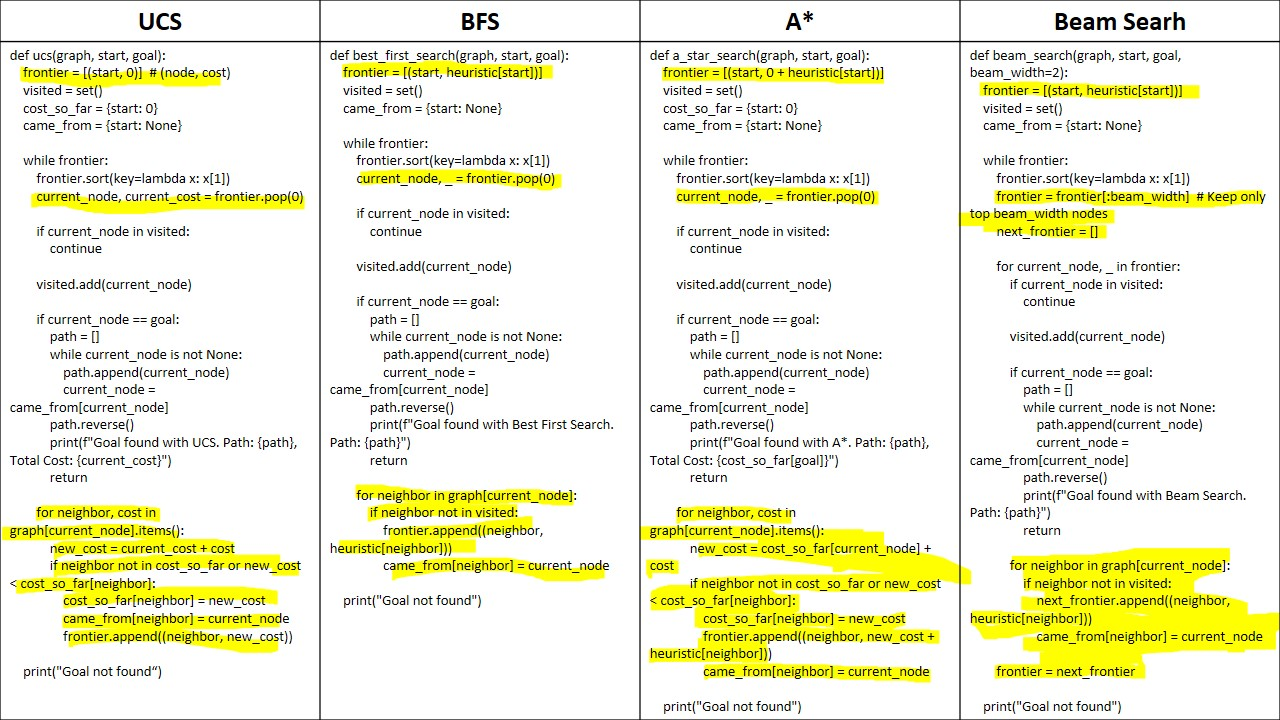

#Example2

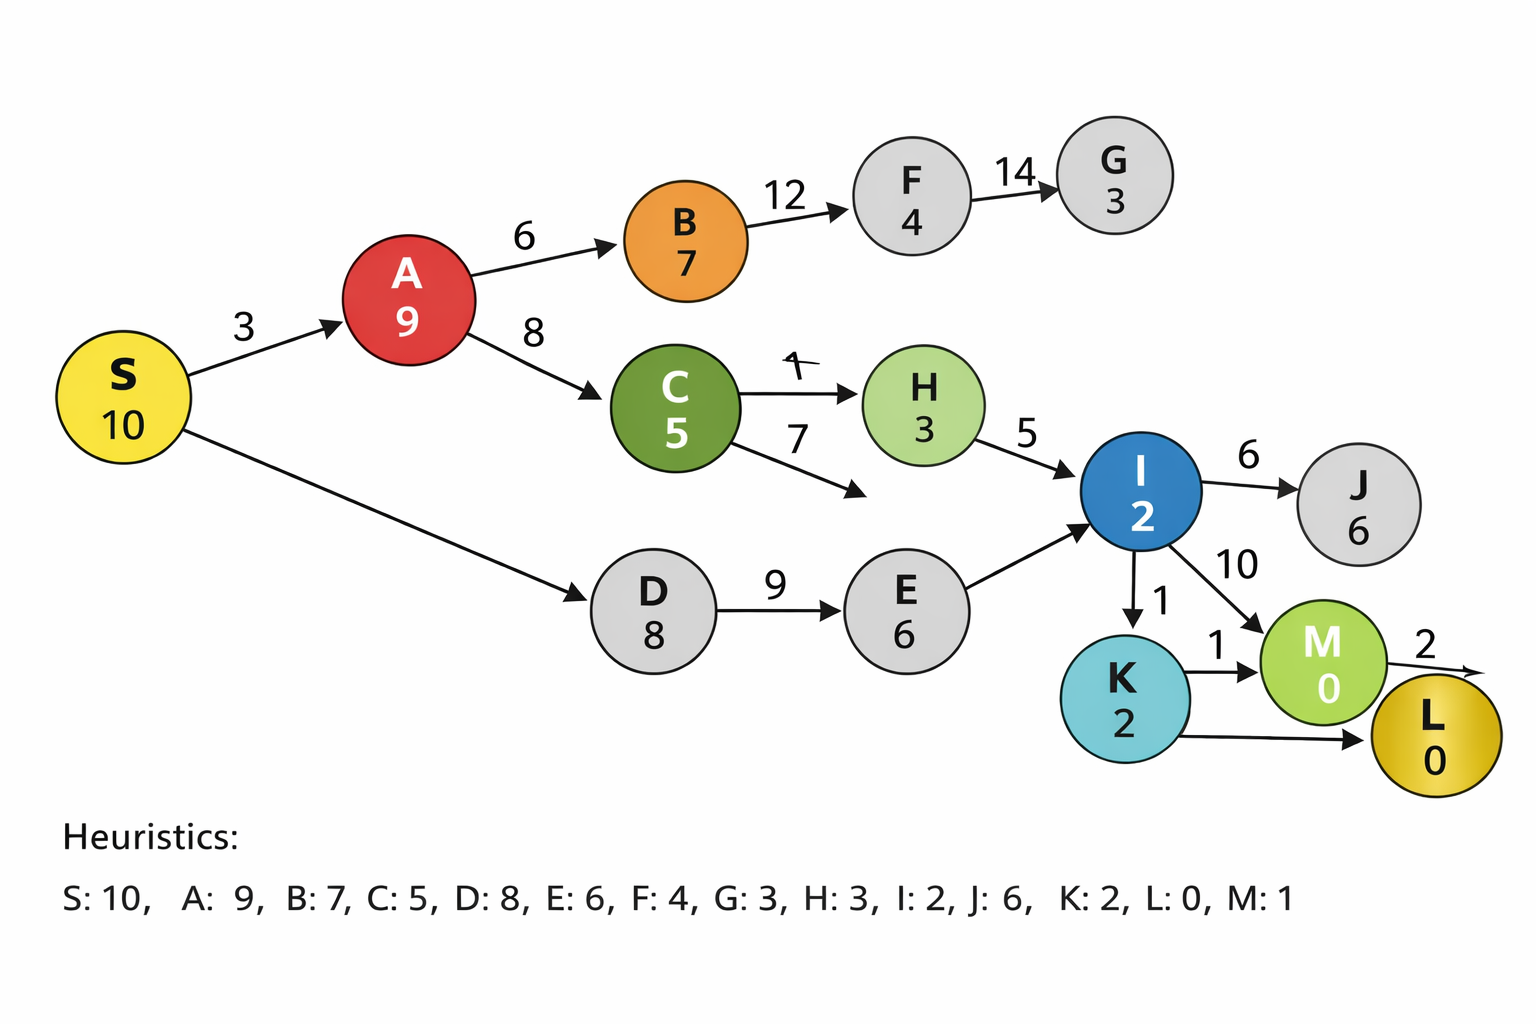

In [ ]:
graph = {
    'S': {'A': 3, 'B': 6, 'C': 5},
    'A': {'D': 9, 'E': 8},
    'B': {'F': 12, 'G': 14},
    'C': {'H': 7},
    'H': {'I': 5, 'J': 6},
    'I': {'K': 1, 'L': 10, 'M': 2},
    'D': {}, 'E': {}, 'F': {}, 'G': {},
    'J': {}, 'K': {}, 'L': {}, 'M': {}
}

heuristic = {
    'S': 10, 'A': 9, 'B': 7, 'C': 5, 'D': 8, 'E': 6, 'F': 4, 'G': 3,
    'H': 3, 'I': 2, 'J': 6, 'K': 2, 'L': 0, 'M': 1
}

def ucs(graph, start, goal):
    frontier = [(start, 0)]  # (node, cost)
    visited = set()
    cost_so_far = {start: 0}
    came_from = {start: None}

    while frontier:
        frontier.sort(key=lambda x: x[1])
        current_node, current_cost = frontier.pop(0)

        if current_node in visited:
            continue

        visited.add(current_node)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node)
                current_node = came_from[current_node]
            path.reverse()
            print(f"Goal found with UCS. Path: {path}, Total Cost: {current_cost}")
            return

        for neighbor, cost in graph[current_node].items():
            new_cost = current_cost + cost
            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                came_from[neighbor] = current_node
                frontier.append((neighbor, new_cost))

    print("Goal not found")

def best_first_search(graph, start, goal):
    frontier = [(start, heuristic[start])]
    visited = set()
    came_from = {start: None}

    while frontier:
        frontier.sort(key=lambda x: x[1])
        current_node, _ = frontier.pop(0)

        if current_node in visited:
            continue

        visited.add(current_node)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node)
                current_node = came_from[current_node]
            path.reverse()
            print(f"Goal found with Best First Search. Path: {path}")
            return

        for neighbor in graph[current_node]:
            if neighbor not in visited:
                frontier.append((neighbor, heuristic[neighbor]))
                came_from[neighbor] = current_node

    print("Goal not found")

def a_star_search(graph, start, goal):
    frontier = [(start, 0 + heuristic[start])]
    visited = set()
    cost_so_far = {start: 0}
    came_from = {start: None}

    while frontier:
        frontier.sort(key=lambda x: x[1])
        current_node, _ = frontier.pop(0)

        if current_node in visited:
            continue

        visited.add(current_node)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node)
                current_node = came_from[current_node]
            path.reverse()
            print(f"Goal found with A*. Path: {path}, Total Cost: {cost_so_far[goal]}")
            return

        for neighbor, cost in graph[current_node].items():
            new_cost = cost_so_far[current_node] + cost
            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                frontier.append((neighbor, new_cost + heuristic[neighbor]))
                came_from[neighbor] = current_node

    print("Goal not found")

def beam_search(graph, start, goal, beam_width=2):
    frontier = [(start, heuristic[start])]
    visited = set()
    came_from = {start: None}

    while frontier:
        frontier.sort(key=lambda x: x[1])
        frontier = frontier[:beam_width]  # Keep only top beam_width nodes
        next_frontier = []

        for current_node, _ in frontier:
            if current_node in visited:
                continue

            visited.add(current_node)

            if current_node == goal:
                path = []
                while current_node is not None:
                    path.append(current_node)
                    current_node = came_from[current_node]
                path.reverse()
                print(f"Goal found with Beam Search. Path: {path}")
                return

            for neighbor in graph[current_node]:
                if neighbor not in visited:
                    next_frontier.append((neighbor, heuristic[neighbor]))
                    came_from[neighbor] = current_node

        frontier = next_frontier

    print("Goal not found")

# Running all algorithms
ucs(graph, 'S', 'L')
best_first_search(graph, 'S', 'L')
a_star_search(graph, 'S', 'L')
beam_search(graph, 'S', 'L')


Goal found with UCS. Path: ['S', 'C', 'H', 'I', 'L'], Total Cost: 27
Goal found with Best First Search. Path: ['S', 'C', 'H', 'I', 'L']
Goal found with A*. Path: ['S', 'C', 'H', 'I', 'L'], Total Cost: 27
Goal found with Beam Search. Path: ['S', 'C', 'H', 'I', 'L']


#Beam vs Bestfirst

In [ ]:
def beam_search(graph, start, goal, beam_width=2):
    frontier = [(start, heuristic[start])]
    visited = set()
    came_from = {start: None}
    all_frontiers = []  # Store all frontiers

    while frontier:
        frontier.sort(key=lambda x: x[1])
        frontier = frontier[:beam_width]  # Keep only top beam_width nodes
        all_frontiers.append(list(frontier))  # Store current frontier
        next_frontier = []

        for current_node, _ in frontier:
            if current_node in visited:
                continue

            visited.add(current_node)

            if current_node == goal:
                path = []
                while current_node is not None:
                    path.append(current_node)
                    current_node = came_from[current_node]
                path.reverse()
                print(f"Goal found with Beam Search. Path: {path}")
                return path, all_frontiers

            for neighbor in graph[current_node]:
                if neighbor not in visited:
                    next_frontier.append((neighbor, heuristic[neighbor]))
                    came_from[neighbor] = current_node

        frontier = next_frontier

    print("Goal not found")
    return None, all_frontiers

def best_first_search(graph, start, goal):
    frontier = [(start, heuristic[start])]
    visited = set()
    came_from = {start: None}
    all_frontiers = []  # Store all frontiers

    while frontier:
        frontier.sort(key=lambda x: x[1])
        all_frontiers.append(list(frontier))  # Store current frontier
        current_node, _ = frontier.pop(0)

        if current_node in visited:
            continue

        visited.add(current_node)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node)
                current_node = came_from[current_node]
            path.reverse()
            print(f"Goal found with Best First Search. Path: {path}")
            return path, all_frontiers

        for neighbor in graph[current_node]:
            if neighbor not in visited:
                frontier.append((neighbor, heuristic[neighbor]))
                came_from[neighbor] = current_node

    print("Goal not found")
    return None, all_frontiers
best_first_search(graph, 'S', 'L')


Goal found with Best First Search. Path: ['S', 'C', 'H', 'I', 'L']


(['S', 'C', 'H', 'I', 'L'],
 [[('S', 10)],
  [('C', 5), ('B', 7), ('A', 9)],
  [('H', 3), ('B', 7), ('A', 9)],
  [('I', 2), ('J', 6), ('B', 7), ('A', 9)],
  [('L', 0), ('M', 1), ('K', 2), ('J', 6), ('B', 7), ('A', 9)]])

In [ ]:
beam_search(graph, 'S', 'L')

Goal found with Beam Search. Path: ['S', 'C', 'H', 'I', 'L']


(['S', 'C', 'H', 'I', 'L'],
 [[('S', 10)],
  [('C', 5), ('B', 7)],
  [('H', 3), ('G', 3)],
  [('I', 2), ('J', 6)],
  [('L', 0), ('M', 1)]])

#**Hill Climbing** (mehak)

In [ ]:
def hill_climbing(graph, start, goal):
    current_node = start
    path = [current_node]

    while current_node != goal:
        neighbors = graph.get(current_node, [])
        if not neighbors:
            print("No path found with Hill Climbing.")
            return None

        # Choose the best neighbor based on the heuristic (lowest value)
        best_neighbor = min(neighbors, key=lambda x: heuristic[x[0]])
        best_neighbor_node = best_neighbor[0]

        # If the best neighbor is worse than the current node, stop (local maximum)
        if heuristic[best_neighbor_node] >= heuristic[current_node]:
            print("Stuck at local maximum. No path found with Hill Climbing.")
            return None

        current_node = best_neighbor_node
        path.append(current_node)

        if current_node == goal:
            print(f"Goal found with Hill Climbing. Path: {path}")
            return path

    print("Goal not found.")
    return None
hill_climbing(graph, 'S', 'I')

Goal found with Hill Climbing. Path: ['S', 'C', 'H', 'I']


['S', 'C', 'H', 'I']

#Solving N-Queens Using Simple Hill Climbing


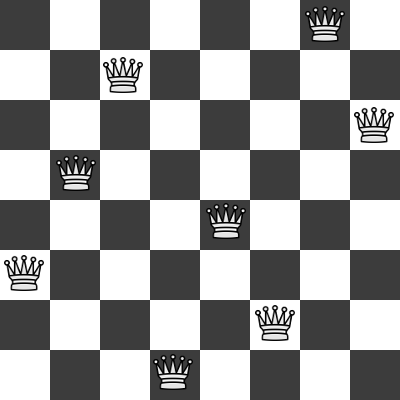

In [ ]:
import random
# Heuristic function: Counts the number of pairs of attacking queens
def calculate_conflicts(state):
    print(state)
    conflicts = 0
    n = len(state)
    for i in range(n):
        for j in range(i + 1, n):
            # Check same column or diagonal
            if state[i] == state[j] or abs(state[i] - state[j]) == abs(i - j):
                conflicts += 1
    return conflicts


# Generate neighbors by moving one queen at a time
def get_neighbors(state):
    neighbors = []
    n = len(state)
    for row in range(n):
        for col in range(n):
            if col != state[row]:
                new_state = list(state)
                new_state[row] = col
                neighbors.append(new_state)
    return neighbors


# Simple Hill Climbing function
def simple_hill_climbing(n):
    # Random initial state
    current_state = [random.randint(0, n - 1) for _ in range(n)]
    current_conflicts = calculate_conflicts(current_state)

    while True:
        neighbors = get_neighbors(current_state)
        next_state = None
        next_conflicts = current_conflicts
        # Find the first better neighbor
        for neighbor in neighbors:
            neighbor_conflicts = calculate_conflicts(neighbor)
            if neighbor_conflicts < next_conflicts:
                next_state = neighbor
                next_conflicts = neighbor_conflicts
                break  # Move to the first better neighbor

        # If no better neighbor is found, return the current state
        if next_conflicts >= current_conflicts:
            break

        # Move to the better neighbor
        current_state = next_state
        current_conflicts = next_conflicts

    return current_state, current_conflicts


# Run Simple Hill Climbing for N-Queens
n = 8  # Change N here for different sizes
solution, conflicts = simple_hill_climbing(4)


# Print results
if conflicts == 0:
    print(f"Solution found for {n}-Queens problem:")
    print(solution)
else:
    print(f"Could not find a solution. Stuck at state with {conflicts} conflicts:")
    print(solution)


[3, 2, 1, 3]
[0, 2, 1, 3]
[1, 2, 1, 3]
[2, 2, 1, 3]
[3, 2, 1, 3]
[0, 0, 1, 3]
[0, 1, 1, 3]
[0, 3, 1, 3]
[0, 2, 0, 3]
[0, 2, 2, 3]
[0, 2, 3, 3]
[0, 2, 1, 0]
[0, 2, 1, 1]
[0, 2, 1, 2]
Could not find a solution. Stuck at state with 2 conflicts:
[0, 2, 1, 3]


In [ ]:
import random

# Heuristic function: Counts the number of pairs of attacking queens
def calculate_conflicts(state):
    conflicts = 0
    n = len(state)
    print("State:", state)
    draw_board(state)  # Draw board for every state explored
    for i in range(n):
        for j in range(i + 1, n):
            if state[i] == state[j] or abs(state[i] - state[j]) == abs(i - j):
                conflicts += 1
    return conflicts

# Generate neighbors by moving one queen at a time
def get_neighbors(state):
    neighbors = []
    n = len(state)
    for row in range(n):
        for col in range(n):
            if col != state[row]:
                new_state = list(state)
                new_state[row] = col
                neighbors.append(new_state)
    return neighbors

# Function to draw the board
def draw_board(state):
    n = len(state)
    for row in range(n):
        line = ""
        for col in range(n):
            if state[row] == col:
                line += " Q "
            else:
                line += " . "
        print(line)
    print("\n")  # spacing

# Simple Hill Climbing function
def simple_hill_climbing(n):
    current_state = [random.randint(0, n - 1) for _ in range(n)]
    current_conflicts = calculate_conflicts(current_state)

    while True:
        neighbors = get_neighbors(current_state)
        next_state = None
        next_conflicts = current_conflicts
        for neighbor in neighbors:
            neighbor_conflicts = calculate_conflicts(neighbor)
            if neighbor_conflicts < next_conflicts:
                next_state = neighbor
                next_conflicts = neighbor_conflicts
                break

        if next_conflicts >= current_conflicts:
            break

        current_state = next_state
        current_conflicts = next_conflicts

    return current_state, current_conflicts

# Run Simple Hill Climbing
n = 8
solution, conflicts = simple_hill_climbing(n)

# Print final result
if conflicts == 0:
    print(f"Solution found for {n}-Queens problem:")
    print(solution)
    draw_board(solution)
else:
    print(f"Could not find a solution. Stuck at state with {conflicts} conflicts:")
    print(solution)
    draw_board(solution)

State: [7, 4, 4, 5, 7, 2, 1, 6]
 .  .  .  .  .  .  .  Q 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  .  Q  .  . 
 .  .  .  .  .  .  .  Q 
 .  .  Q  .  .  .  .  . 
 .  Q  .  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 


State: [0, 4, 4, 5, 7, 2, 1, 6]
 Q  .  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  .  Q  .  . 
 .  .  .  .  .  .  .  Q 
 .  .  Q  .  .  .  .  . 
 .  Q  .  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 


State: [1, 4, 4, 5, 7, 2, 1, 6]
 .  Q  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  .  Q  .  . 
 .  .  .  .  .  .  .  Q 
 .  .  Q  .  .  .  .  . 
 .  Q  .  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 


State: [2, 4, 4, 5, 7, 2, 1, 6]
 .  .  Q  .  .  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  .  Q  .  . 
 .  .  .  .  .  .  .  Q 
 .  .  Q  .  .  .  .  . 
 .  Q  .  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 


State: [3, 4, 4, 5, 7, 2, 1, 6]
 .  .  .  Q  .  .  .  . 
 .  .  

###4 Queeen

In [ ]:
import random

# Heuristic function: Counts number of attacking queen pairs
def calculate_conflicts(state):
    conflicts = 0
    n = len(state)
    conflict_positions = set()  # Keep track of queens in conflict
    for i in range(n):
        for j in range(i + 1, n):
            if state[i] == state[j] or abs(state[i] - state[j]) == abs(i - j):
                conflicts += 1
                conflict_positions.add(i)
                conflict_positions.add(j)
    return conflicts, conflict_positions

# Generate neighbors by moving one queen at a time
def get_neighbors(state):
    neighbors = []
    n = len(state)
    for row in range(n):
        for col in range(n):
            if col != state[row]:
                new_state = list(state)
                new_state[row] = col
                neighbors.append(new_state)
    return neighbors

# Function to print the board with conflicts
def print_board(state, conflict_positions):
    n = len(state)
    print("\nBoard:")
    for row in range(n):
        line = ""
        for col in range(n):
            if state[row] == col:
                if row in conflict_positions:
                    line += " Q "  # Queen in conflict
                else:
                    line += " q "  # Safe queen
            else:
                line += " . "
        print(line)
    print()

# Simple Hill Climbing function
def simple_hill_climbing(n):
    current_state = [random.randint(0, n - 1) for _ in range(n)]
    current_conflicts, conflict_positions = calculate_conflicts(current_state)
    print_board(current_state, conflict_positions)

    while True:
        neighbors = get_neighbors(current_state)
        next_state = None
        next_conflicts = current_conflicts
        next_conflict_positions = conflict_positions

        for neighbor in neighbors:
            neighbor_conflicts, neighbor_conflicts_pos = calculate_conflicts(neighbor)
            if neighbor_conflicts < next_conflicts:
                next_state = neighbor
                next_conflicts = neighbor_conflicts
                next_conflict_positions = neighbor_conflicts_pos
                break  # Move to the first better neighbor

        if next_conflicts >= current_conflicts:
            break

        current_state = next_state
        current_conflicts = next_conflicts
        conflict_positions = next_conflict_positions
        print_board(current_state, conflict_positions)

    return current_state, current_conflicts

# Run for N-Queens
n = 4
solution, conflicts = simple_hill_climbing(n)

if conflicts == 0:
    print(f"Solution found for {n}-Queens problem: {solution}")
else:
    print(f"Stuck at state with {conflicts} conflicts: {solution}")


Board:
 .  Q  .  . 
 .  Q  .  . 
 .  Q  .  . 
 .  Q  .  . 


Board:
 Q  .  .  . 
 .  Q  .  . 
 .  Q  .  . 
 .  Q  .  . 


Board:
 Q  .  .  . 
 Q  .  .  . 
 .  Q  .  . 
 .  Q  .  . 


Board:
 .  .  q  . 
 Q  .  .  . 
 .  Q  .  . 
 .  Q  .  . 


Board:
 .  .  q  . 
 q  .  .  . 
 .  .  .  q 
 .  q  .  . 

Solution found for 4-Queens problem: [2, 0, 3, 1]


#Genetic Algorithm

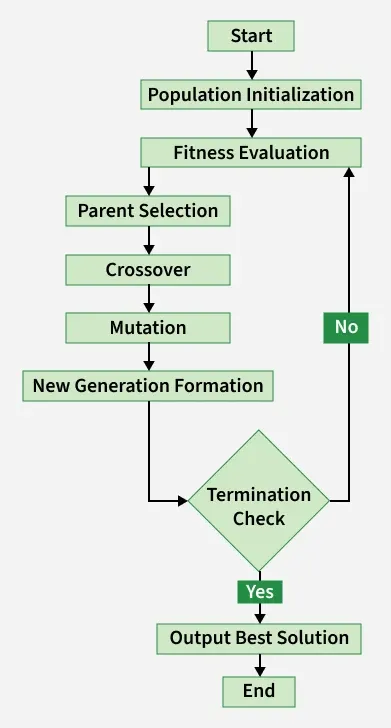

In [ ]:
# ======== ====== ===== Types of Selection Functions
# Roulette Wheel Selection
# Rank-Based Selection
# Tournament Selection
# Truncation Selection
# Boltzmann Selection
# Random Selection

In [ ]:
import random

# Fitness Evaluation (Example: Counting ones in a binary chromosome)
def fitness(chromosome):
    return sum(chromosome)

# Selection (Roulette Wheel Selection)
def roulette_wheel_selection(population, fitness_values):
    total_fitness = sum(fitness_values)
    probabilities = [fitness / total_fitness for fitness in fitness_values]
    selected = random.choices(population, probabilities, k=2)  # Select 2 parents
    return selected

# Crossover (Single-point crossover)
def crossover(parent1, parent2):
    crossover_point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:crossover_point] + parent2[crossover_point:]
    child2 = parent2[:crossover_point] + parent1[crossover_point:]
    return child1, child2

# Mutation (Bit-flip mutation)
def mutate(chromosome, mutation_rate):
    for i in range(len(chromosome)):
        if random.random() < mutation_rate:
            chromosome[i] = 1 - chromosome[i]  # Flip the bit
    return chromosome

# Genetic Algorithm
def genetic_algorithm(initial_population, generations, mutation_rate):
    population = initial_population
    for generation in range(generations):
        # Fitness evaluation
        fitness_values = [fitness(chromosome) for chromosome in population]

        # Selection
        parents = roulette_wheel_selection(population, fitness_values)

        # Crossover
        Y = [crossover(parents[0], parents[1]) for _ in range(len(population) // 2)]
        offspring = [gene for sublist in offspring for gene in sublist]  # Flatten the list

        # Mutation
        mutated_offspring = [mutate(chromosome, mutation_rate) for chromosome in offspring]

        # Replace the old population with the new one
        population = mutated_offspring

    # Return the best chromosome after all generations
    best_chromosome = max(population, key=fitness)
    # print('best_chromosome',best_chromosome)
    return best_chromosome

# Initial population
initial_population = [
    [0, 1, 1, 0, 1],
    [1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [1, 0, 0, 1, 1]
]

# Genetic Algorithm parameters
generations = 50
mutation_rate = 0.01

# Apply GA
best_solution = genetic_algorithm(initial_population, generations, mutation_rate)
print("Best solution:", best_solution)
print("Fitness:", fitness(best_solution))

Best solution: [1, 1, 1, 0, 1]
Fitness: 4


###Step by step ==================

In [3]:
# Initial population
initial_population = [
    [0, 1, 1, 0, 1],
    [1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [1, 0, 0, 1, 1]
]

In [5]:
# Fitness Evaluation (Example: Counting ones in a binary chromosome)
def fitness(chromosome):
    return sum(chromosome)

fitness(initial_population[0])

3

In [4]:
for chromosome in initial_population:
    print(chromosome)

[0, 1, 1, 0, 1]
[1, 1, 0, 0, 0]
[0, 1, 0, 0, 0]
[1, 0, 0, 1, 1]


In [ ]:
fitness_values = []
for chromosome in initial_population:
    fitness_values.append(fitness(chromosome))
print(fitness_values)

[3, 2, 1, 3]


In [ ]:
# Genetic Algorithm
def genetic_algorithm(initial_population, generations, mutation_rate):
    population = initial_population
    for generation in range(generations):
        # Fitness evaluation
        fitness_values = [fitness(chromosome) for chromosome in population]
        print(fitness_values)

genetic_algorithm(initial_population,2,0.1)

[3, 2, 1, 3]
[3, 2, 1, 3]


In [ ]:
# choices = random.choices(['apple', 'banana', 'cherry'], weights=[1, 3, 1], k=5)
# print(choices)
# # 'banana' is more likely to be selected because it has a higher weight (3).


In [ ]:
initial_population = [
    [0, 1, 1, 0, 1],
    [1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [1, 0, 0, 1, 1]
]

probabilities = []
total_fitness = sum(fitness_values) #3+2+1+3 = 9
for fitness in fitness_values:
    probabilities.append(fitness / total_fitness)

print('probabilities',probabilities)

selected = random.choices(initial_population, probabilities, k=2)  # Select 2 parents
selected

probabilities [0.3333333333333333, 0.2222222222222222, 0.1111111111111111, 0.3333333333333333]


[[1, 1, 0, 0, 0], [1, 1, 0, 0, 0]]

In [ ]:
import random
# Selection (Roulette Wheel Selection)
def roulette_wheel_selection(population, fitness_values):
    total_fitness = sum(fitness_values) #3+2+1+3 = 9
    probabilities = [fitness / total_fitness for fitness in fitness_values]
    selected = random.choices(population, probabilities, k=2)  # Select 2 parents
    return selected

parents=roulette_wheel_selection(initial_population,fitness_values)
parents

[[0, 1, 1, 0, 1], [1, 0, 0, 1, 1]]

In [ ]:
# Crossover (Single-point crossover)
def crossover(parent1, parent2):
    crossover_point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:crossover_point] + parent2[crossover_point:]
    child2 = parent2[:crossover_point] + parent1[crossover_point:]
    return child1, child2
# crossover(parents[0], parents[1])
# Crossover
offspring = [crossover(parents[0], parents[1]) for _ in range(len(initial_population) // 2)]
offspring = [gene for sublist in offspring for gene in sublist]  # Flatten the list
offspring

[[0, 0, 0, 1, 1], [1, 1, 1, 0, 1], [0, 0, 0, 1, 1], [1, 1, 1, 0, 1]]

In [ ]:
parent1=[0, 1, 1, 0, 1]
parent2=[1, 1, 0, 0, 0]
crossover_point = random.randint(1, len(parent1) - 1)   #randint(1,4) generate random integer where we split
crossover_point

4

In [ ]:
child1 = parent1[:crossover_point] + parent2[crossover_point:]
child1

# [0, 1, 1, 0, 1] ... split here  [0, 1, 1 / 0, 1] ..p1
# [1, 1, 0, 0, 0].... split here  [1, 1, 0/ 0, 0] .... p2
# soooo .... p1 stating bit remain same  [0,1,1] but later 2 bit swapped with p2 bits [{0:0,1:0}].. final : [0,1,1,0,0]


[0, 1, 1, 0, 0]

In [ ]:
len(initial_population) // 2

2

In [ ]:
offspring = []
for _ in range(len(initial_population) // 2):
    offspring.append(crossover(parents[0], parents[1]))
offspring


[([0, 0, 0, 1, 1], [1, 1, 1, 0, 1]), ([0, 0, 0, 1, 1], [1, 1, 1, 0, 1])]

In [ ]:
offspring = [gene for sublist in offspring for gene in sublist]  # Flatten the list
offspring

[[0, 0, 0, 1, 1], [1, 1, 1, 0, 1], [0, 0, 0, 1, 1], [1, 1, 1, 0, 1]]

In [ ]:
# Mutation
# Mutation (Bit-flip mutation)
def mutate(chromosome, mutation_rate):
    for i in range(len(chromosome)):
        if random.random() < mutation_rate:
            chromosome[i] = 1 - chromosome[i]  # Flip the bit
    return chromosome

mutate(offspring[0],0.1)
# mutated_offspring = [mutate(chromosome, mutation_rate) for chromosome in offspring]



[0, 0, 0, 1, 0]

In [ ]:

# Initial population
initial_population = [
    [0, 1, 1, 0, 1],
    [1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [1, 0, 0, 1, 1]
]
best_chromosome = max(initial_population, key=fitness)
# print('best_chromosome',best_chromosome)
best_chromosome


[1, 1, 0, 0, 0]

#N-Queen using GA

**GA**

In [ ]:
import random

# Define the number of queens
n = 8

# Fitness function: counts non-attacking pairs of queens
def calculate_fitness(individual):
    non_attacking_pairs = 0
    total_pairs = n * (n - 1) // 2  # Maximum possible non-attacking pairs

    # Check for conflicts
    for i in range(n):
        for j in range(i + 1, n):
            # No same column or diagonal conflict
            if individual[i] != individual[j] and abs(individual[i] - individual[j]) != abs(i - j):
                non_attacking_pairs += 1

    # Fitness score is the ratio of non-attacking pairs
    return non_attacking_pairs / total_pairs


In [ ]:
# Generate a random individual (chromosome) based on column positions
def create_random_individual():
    return random.sample(range(n), n)  # Ensure unique column positions
# create_random_individual()
# Create an initial population of random individuals
population_size = 10
population = [create_random_individual() for _ in range(population_size)]
population

[[4, 2, 3, 6, 7, 1, 5, 0],
 [5, 6, 2, 0, 1, 4, 7, 3],
 [1, 6, 2, 0, 7, 4, 5, 3],
 [5, 1, 7, 0, 4, 2, 6, 3],
 [4, 2, 3, 7, 1, 0, 6, 5],
 [3, 2, 7, 0, 1, 4, 5, 6],
 [7, 3, 0, 2, 6, 4, 5, 1],
 [0, 5, 6, 1, 7, 4, 3, 2],
 [5, 3, 0, 4, 2, 7, 6, 1],
 [1, 3, 6, 2, 4, 0, 7, 5]]

In [ ]:
def print_board(individual):
    n = len(individual)
    for row in range(n):
        line = ["Q" if col == individual[row] else "." for col in range(n)]
        print(" ".join(line))
    print("\n")

# Example
individual = [7, 1, 5, 3, 2, 0, 6, 4]
print_board(individual)


. . . . . . . Q
. Q . . . . . .
. . . . . Q . .
. . . Q . . . .
. . Q . . . . .
Q . . . . . . .
. . . . . . Q .
. . . . Q . . .




In [ ]:
# Evaluate fitness for each individual
fitness_scores = [calculate_fitness(ind) for ind in population]
print("Fitness Scores:", fitness_scores)

Fitness Scores: [0.8928571428571429, 0.8928571428571429, 0.9285714285714286, 0.8214285714285714, 0.7857142857142857, 0.7142857142857143, 0.8571428571428571, 0.8571428571428571, 0.8928571428571429, 0.8928571428571429]


In [ ]:
# Select parents based on fitness
def select_parents(population, fitness_scores):
    sorted_population = [route for _, route in sorted(zip(fitness_scores, population), reverse=True)]
    return sorted_population[:len(population) // 2]

# Select parents
parents = select_parents(population, fitness_scores)
print("Selected Parents:", parents)


Selected Parents: [[4, 2, 0, 5, 7, 6, 1, 3], [0, 7, 5, 4, 6, 1, 3, 2], [5, 4, 0, 3, 2, 7, 1, 6], [5, 0, 6, 7, 3, 1, 4, 2], [4, 7, 0, 5, 3, 2, 6, 1]]


In [ ]:
# # Select parents based on fitness
# def select_parents(population, fitness_scores):
#     # Combine fitness scores with population
#     combined = list(zip(fitness_scores, population))
#     print('combined',combined)

#     # Sort based on fitness (higher is better)
#     combined.sort(reverse=True, key=lambda x: x[0])

#     # Extract the sorted population
#     sorted_population = []
#     for _, route in combined:
#         sorted_population.append(route)
#     print('sorted_population',sorted_population)

#     # Select the top 50% as parents
#     num_parents = len(population) // 2
#     parents = []
#     for i in range(num_parents):
#         parents.append(sorted_population[i])

#     return parents

# # Example Usage
# population = [[2, 0, 3, 1], [1, 3, 0, 2], [3, 1, 2, 0], [0, 2, 1, 3]]
# fitness_scores = [0.8, 0.6, 0.9, 0.7]  # Higher is better

# # Select parents
# parents = select_parents(population, fitness_scores)
# print("Selected Parents:", parents)


combined [(0.8, [2, 0, 3, 1]), (0.6, [1, 3, 0, 2]), (0.9, [3, 1, 2, 0]), (0.7, [0, 2, 1, 3])]
sorted_population [[3, 1, 2, 0], [2, 0, 3, 1], [0, 2, 1, 3], [1, 3, 0, 2]]
Selected Parents: [[3, 1, 2, 0], [2, 0, 3, 1]]


In [ ]:
# Crossover function: single-point crossover with unique column positions
def crossover(parent1, parent2):
    point = random.randint(1, n - 2)  # Choose a crossover point
    child = parent1[:point] + parent2[point:]

    # Ensure unique column positions
    missing = set(range(n)) - set(child)
    duplicates = [col for col in child if child.count(col) > 1]
    for i in range(len(child)):
        if child.count(child[i]) > 1:
            child[i] = missing.pop()
    return child

# Create new population using crossover
new_population = []
for _ in range(population_size):
    parent1, parent2 = random.sample(parents, 2)
    child = crossover(parent1, parent2)
    new_population.append(child)
print("New Population after Crossover:", new_population)


New Population after Crossover: [[0, 2, 3, 1], [3, 1, 2, 0], [3, 1, 2, 0], [0, 2, 3, 1], [1, 3, 2, 0], [2, 0, 3, 1], [3, 1, 2, 0], [2, 0, 3, 1], [2, 0, 3, 1], [2, 0, 3, 1]]


In [ ]:
# Mutation function: swap two column positions
def mutate(individual):
    idx1, idx2 = random.sample(range(n), 2)
    individual[idx1], individual[idx2] = individual[idx2], individual[idx1]
    return individual

# Apply mutation with a probability of 0.1
mutation_rate = 0.1
for i in range(len(new_population)):
    if random.random() < mutation_rate:
        new_population[i] = mutate(new_population[i])
print("Population after Mutation:", new_population)


Population after Mutation: [[0, 7, 5, 4, 2, 6, 1, 3], [4, 2, 0, 5, 7, 3, 6, 1], [5, 1, 0, 3, 6, 7, 4, 2], [5, 0, 4, 7, 6, 1, 3, 2], [7, 0, 5, 4, 6, 1, 3, 2], [4, 7, 0, 5, 3, 2, 6, 1], [0, 7, 5, 4, 6, 1, 3, 2], [5, 7, 0, 4, 6, 1, 3, 2], [0, 5, 6, 7, 3, 1, 4, 2], [0, 7, 5, 4, 2, 3, 6, 1]]


In [ ]:
# Genetic Algorithm main function
def genetic_algorithm():
    population = [create_random_individual() for _ in range(population_size)]
    generation = 0
    best_fitness = 0

    while best_fitness < 1.0 and generation < 100:
        fitness_scores = [calculate_fitness(ind) for ind in population]
        best_fitness = max(fitness_scores)
        print(f"Generation {generation} Best Fitness: {best_fitness}")

        # Check for optimal solution
        if best_fitness == 1.0:
            break

        # Selection
        parents = select_parents(population, fitness_scores)

        # Crossover
        new_population = [crossover(random.choice(parents), random.choice(parents)) for _ in range(population_size)]

        # Mutation
        for i in range(len(new_population)):
            if random.random() < mutation_rate:
                new_population[i] = mutate(new_population[i])

        population = new_population
        generation += 1

    # Return the best solution
    best_individual = max(population, key=calculate_fitness)
    return best_individual, calculate_fitness(best_individual)

# Run the Genetic Algorithm
solution, fitness = genetic_algorithm()
print("Best Solution:", solution)
print("Best Fitness:", fitness)


Generation 0 Best Fitness: 0.9285714285714286
Generation 1 Best Fitness: 0.9285714285714286
Generation 2 Best Fitness: 0.9642857142857143
Generation 3 Best Fitness: 0.9642857142857143
Generation 4 Best Fitness: 0.8928571428571429
Generation 5 Best Fitness: 0.8928571428571429
Generation 6 Best Fitness: 0.8928571428571429
Generation 7 Best Fitness: 0.8928571428571429
Generation 8 Best Fitness: 0.8928571428571429
Generation 9 Best Fitness: 0.8928571428571429
Generation 10 Best Fitness: 0.8928571428571429
Generation 11 Best Fitness: 0.8928571428571429
Generation 12 Best Fitness: 0.8928571428571429
Generation 13 Best Fitness: 0.9642857142857143
Generation 14 Best Fitness: 0.9642857142857143
Generation 15 Best Fitness: 0.9642857142857143
Generation 16 Best Fitness: 0.9642857142857143
Generation 17 Best Fitness: 0.9642857142857143
Generation 18 Best Fitness: 0.9642857142857143
Generation 19 Best Fitness: 0.9642857142857143
Generation 20 Best Fitness: 0.9642857142857143
Generation 21 Best Fitn